# PENGWIN Dataset - Análisis Exploratorio de Datos de Entrada (EDA)
**Proyecto Integrador Corte 2 - Analítica de Datos**  
**Universidad Autónoma de Occidente (Semestre 2026-2)**

Este notebook realiza la auditoría de calidad y extracción de metadatos de los volúmenes CT del dataset **PENGWIN**:
1. Indexación robusta por carpetas (`PENGWIN_CT_train_images_part1`, `part2` y `PENGWIN_CT_train_labels`).
2. Lectura universal con `SimpleITK` para compatibilidad nativa con `.mha` y `.nii.gz`.
3. Extracción de metadatos: Dimensiones, Voxel Spacing físico ($dx, dy, dz$) y anisotropía.
4. Análisis de intensidades Hounsfield (HU) y detección de artefactos metálicos (>2500 HU).
5. Verificación de la taxonomía oficial (Sacro: 1-10, Coxal Izquierdo: 11-20, Coxal Derecho: 21-30).
6. Auditoría de fragmentos sanos vs fracturados y reporte de calidad de datos limpios vs atípicos.

In [ ]:
# Instalación de librerías médicas necesarias si no están presentes
#!pip install --quiet SimpleITK nibabel seaborn tqdm


[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: C:\Users\USER\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
import os
import glob
from pathlib import Path
import numpy as np
import pandas as pd
import SimpleITK as sitk
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# Configuración estética
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["font.size"] = 10

# Rutas exactas del proyecto
BASE_DIR = Path(r"C:\Users\USER\OneDrive - Universidad Autonoma de Occidente\8 vo semestre\Analitica de datos\Proyecto\Corte 2")
DATA_DIR = BASE_DIR / "data"
EDA_DIR = BASE_DIR / "EDA"
EDA_DIR.mkdir(parents=True, exist_ok=True)

print(f"Directorio de datos: {DATA_DIR}")
print(f"Directorio EDA: {EDA_DIR}")

Directorio de datos: C:\Users\USER\OneDrive - Universidad Autonoma de Occidente\8 vo semestre\Analitica de datos\Proyecto\Corte 2\data
Directorio EDA: C:\Users\USER\OneDrive - Universidad Autonoma de Occidente\8 vo semestre\Analitica de datos\Proyecto\Corte 2\EDA


In [3]:
# Indexación explícita según el árbol de carpetas
image_dirs = [
    DATA_DIR / "PENGWIN_CT_train_images_part1",
    DATA_DIR / "PENGWIN_CT_train_images_part2"
]
labels_dir = DATA_DIR / "PENGWIN_CT_train_labels"

images_dict = {}
labels_dict = {}

# 1. Indexar imágenes
for img_folder in image_dirs:
    if img_folder.exists():
        for f in img_folder.rglob("*.*"):
            if f.is_file() and f.suffix.lower() in [".mha", ".nii", ".gz"]:
                case_id = f.name.replace(".nii.gz", "").replace(".nii", "").replace(".mha", "")
                images_dict[case_id] = f

# 2. Indexar etiquetas
if labels_dir.exists():
    for f in labels_dir.rglob("*.*"):
        if f.is_file() and f.suffix.lower() in [".mha", ".nii", ".gz"]:
            case_id = f.name.replace(".nii.gz", "").replace(".nii", "").replace(".mha", "")
            labels_dict[case_id] = f

# 3. Casos emparejados
common_cases = sorted(list(set(images_dict.keys()).intersection(set(labels_dict.keys()))))

print(f"Total Imágenes encontradas: {len(images_dict)}")
print(f"Total Máscaras encontradas: {len(labels_dict)}")
print(f"Casos perfectamente emparejados: {len(common_cases)}")

if len(common_cases) > 0:
    print(f"Ejemplo de ID emparejado: {common_cases[0]}")
    print(f" -> Imagen: {images_dict[common_cases[0]].name}")
    print(f" -> Máscara: {labels_dict[common_cases[0]].name}")
else:
    print("[ALERTA] Revise los nombres de archivos dentro de las carpetas.")

Total Imágenes encontradas: 100
Total Máscaras encontradas: 100
Casos perfectamente emparejados: 100
Ejemplo de ID emparejado: 001
 -> Imagen: 001.mha
 -> Máscara: 001.mha


In [4]:
# Función auxiliar para cargar volúmenes con SimpleITK
def load_sitk_volume(path):
    """Lee archivos .mha o .nii y entrega (array_zyx, dims_xyz, spacing_xyz)"""
    reader = sitk.ImageFileReader()
    reader.SetFileName(str(path))
    image = reader.Execute()
    
    # SimpleITK GetArrayFromImage retorna dimensión en orden (Z, Y, X)
    data = sitk.GetArrayFromImage(image)
    dim_x, dim_y, dim_z = image.GetSize()      # Tamaño en píxeles (X, Y, Z)
    dx, dy, dz = image.GetSpacing()            # Espaciado físico mm (dx, dy, dz)
    return data, (dim_x, dim_y, dim_z), (dx, dy, dz)

print("Función de carga inicializada correctamente.")

Función de carga inicializada correctamente.


In [5]:
metadata_records = []

print(f"Extrayendo metadatos y estadísticas de {len(common_cases)} volúmenes...")
for case_id in tqdm(common_cases):
    img_path = images_dict[case_id]
    lbl_path = labels_dict[case_id]
    
    img_data, (dim_x, dim_y, dim_z), (dx, dy, dz) = load_sitk_volume(img_path)
    lbl_data, (ldim_x, ldim_y, ldim_z), _ = load_sitk_volume(lbl_path)
    
    # Validación de dimensiones consistentes
    shape_match = (dim_x == ldim_x and dim_y == ldim_y and dim_z == ldim_z)
    
    # Estadísticas HU en el volumen
    hu_min = float(np.min(img_data))
    hu_max = float(np.max(img_data))
    hu_mean = float(np.mean(img_data))
    hu_p99 = float(np.percentile(img_data, 99))
    
    # Análisis de etiquetas conforme a la taxonomía oficial PENGWIN
    lbl_data = lbl_data.astype(np.int16)
    unique_labels = np.unique(lbl_data)
    unique_labels = unique_labels[unique_labels > 0]
    
    sacrum_frags = [l for l in unique_labels if 1 <= l <= 10]
    left_hip_frags = [l for l in unique_labels if 11 <= l <= 20]
    right_hip_frags = [l for l in unique_labels if 21 <= l <= 30]
    anomalous_labels = [l for l in unique_labels if l > 30]
    
    # Cortes en Z con presencia de tejido óseo
    # En shape (Z, Y, X), el eje 0 es Z
    slices_with_bone = int(np.sum(np.any(lbl_data > 0, axis=(1, 2))))
    
    voxel_vol = dx * dy * dz
    bone_voxels = int(np.sum(lbl_data > 0))
    bone_vol_cm3 = (bone_voxels * voxel_vol) / 1000.0
    
    metadata_records.append({
        "case_id": case_id,
        "dim_x": dim_x,
        "dim_y": dim_y,
        "dim_z": dim_z,
        "dx_mm": round(dx, 4),
        "dy_mm": round(dy, 4),
        "dz_mm": round(dz, 4),
        "voxel_vol_mm3": round(voxel_vol, 4),
        "shape_match": shape_match,
        "hu_min": round(hu_min, 1),
        "hu_max": round(hu_max, 1),
        "hu_mean": round(hu_mean, 1),
        "hu_p99": round(hu_p99, 1),
        "total_fragments": len(unique_labels),
        "n_sacrum_frags": len(sacrum_frags),
        "n_left_hip_frags": len(left_hip_frags),
        "n_right_hip_frags": len(right_hip_frags),
        "n_anomalous_labels": len(anomalous_labels),
        "bone_volume_cm3": round(bone_vol_cm3, 2),
        "slices_with_bone": slices_with_bone,
        "bone_slice_ratio": round(slices_with_bone / dim_z, 4)
    })

df_eda = pd.DataFrame(metadata_records)
df_eda.to_csv(EDA_DIR / "resumen_metadatos_pengwin.csv", index=False)
print(f"Extracción completada: {len(df_eda)} registros procesados y guardados en resumen_metadatos_pengwin.csv.")
df_eda.head()

Extrayendo metadatos y estadísticas de 100 volúmenes...


100%|██████████| 100/100 [03:31<00:00,  2.11s/it]

Extracción completada: 100 registros procesados y guardados en resumen_metadatos_pengwin.csv.


,case_id,dim_x,dim_y,dim_z,dx_mm,dy_mm,dz_mm,voxel_vol_mm3,shape_match,hu_min,...,hu_mean,hu_p99,total_fragments,n_sacrum_frags,n_left_hip_frags,n_right_hip_frags,n_anomalous_labels,bone_volume_cm3,slices_with_bone,bone_slice_ratio
0,001,512,512,401,0.7812,0.7812,0.8,0.4883,True,-1023.0,...,-501.8,507.0,4,1,2,1,0,1039.57,291,0.7257
1,002,413,276,337,0.8242,0.8242,0.8,0.5435,True,-1023.0,...,-307.5,593.0,6,2,1,3,0,744.80,258,0.7656
2,003,512,381,285,0.7598,0.7598,1.0,0.5772,True,-1023.0,...,-427.2,625.0,6,1,4,1,0,757.68,213,0.7474
3,004,386,254,224,0.8438,0.8438,1.0,0.7119,True,-1418.0,...,-187.2,698.0,6,2,2,2,0,598.89,183,0.8170
4,005,512,512,312,0.8965,0.8965,1.0,0.8037,True,-1023.0,...,-688.6,304.0,6,1,2,3,0,642.75,193,0.6186


=== ESTADÍSTICAS GLOBALES DEL DATASET ===


,dim_z,dx_mm,dz_mm,hu_max,total_fragments,bone_volume_cm3,bone_slice_ratio
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
mean,321.060000,0.818526,0.890759,5505.090000,5.750000,781.058600,0.760960
std,43.495227,0.079229,0.108798,7218.223656,1.217507,116.392535,0.064425
min,193.000000,0.658200,0.625000,1422.000000,3.000000,551.190000,0.618600
25%,285.750000,0.781200,0.800000,1677.000000,5.000000,693.740000,0.715450
50%,326.000000,0.797900,0.801000,2345.500000,6.000000,769.190000,0.762250
75%,350.000000,0.858000,1.000000,5433.750000,7.000000,860.245000,0.801250
max,414.000000,1.220000,1.250000,47685.000000,9.000000,1095.230000,0.931900


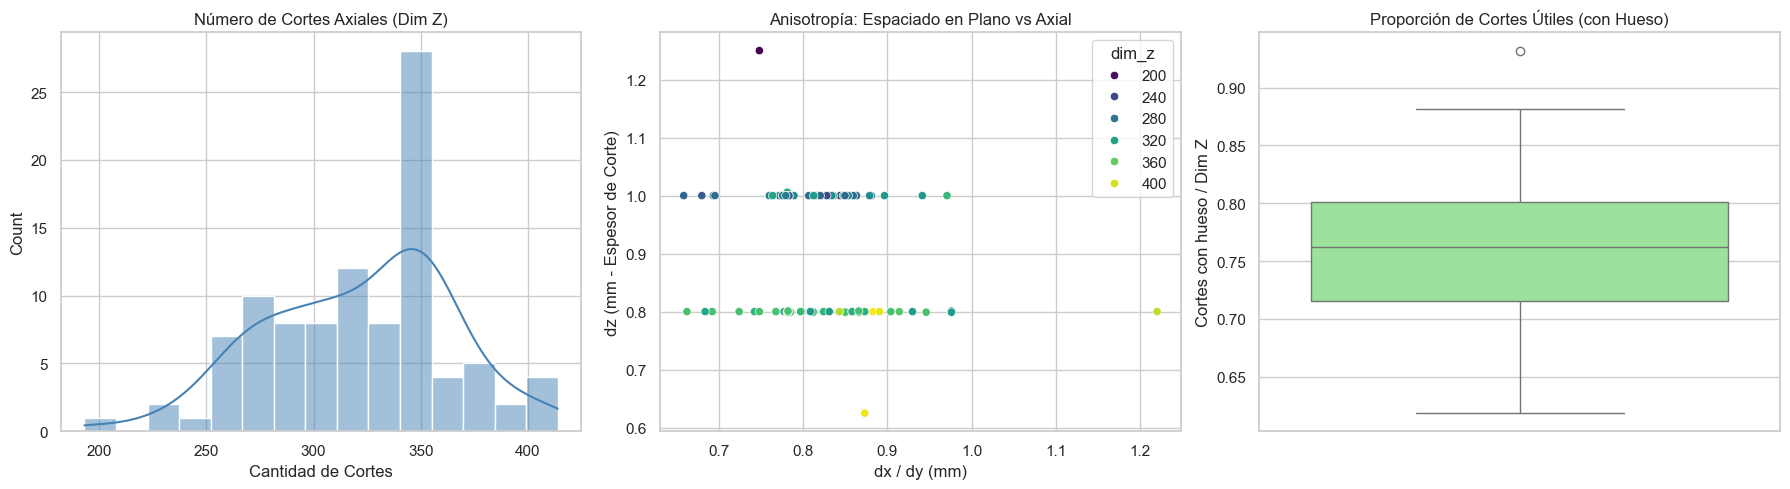

In [6]:
print("=== ESTADÍSTICAS GLOBALES DEL DATASET ===")
display(df_eda[["dim_z", "dx_mm", "dz_mm", "hu_max", "total_fragments", "bone_volume_cm3", "bone_slice_ratio"]].describe())

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(df_eda["dim_z"], kde=True, ax=axes[0], color="steelblue", bins=15)
axes[0].set_title("Número de Cortes Axiales (Dim Z)")
axes[0].set_xlabel("Cantidad de Cortes")

sns.scatterplot(data=df_eda, x="dx_mm", y="dz_mm", hue="dim_z", palette="viridis", ax=axes[1])
axes[1].set_title("Anisotropía: Espaciado en Plano vs Axial")
axes[1].set_xlabel("dx / dy (mm)")
axes[1].set_ylabel("dz (mm - Espesor de Corte)")

sns.boxplot(y=df_eda["bone_slice_ratio"], ax=axes[2], color="lightgreen")
axes[2].set_title("Proporción de Cortes Útiles (con Hueso)")
axes[2].set_ylabel("Cortes con hueso / Dim Z")

plt.tight_layout()
plt.savefig(EDA_DIR / "distribucion_espacial.png", dpi=300)
plt.show()

=== AUDITORÍA DE INTENSIDADES (HU) Y ARTEFACTOS METÁLICOS ===


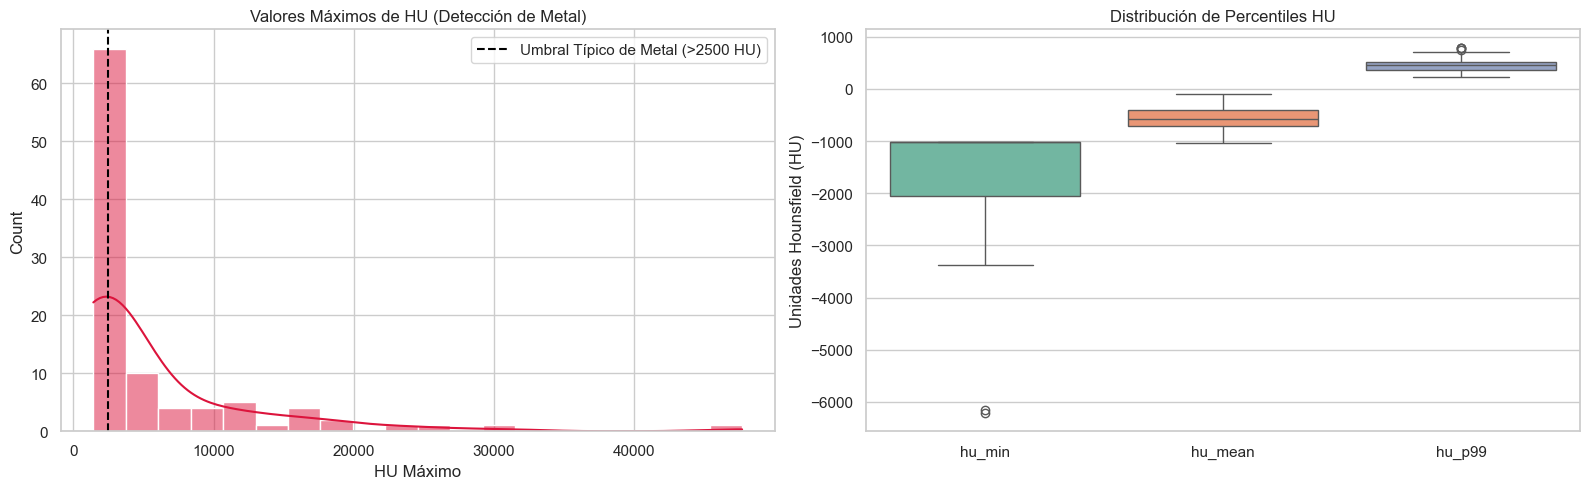

Casos con presencia de material quirúrgico / implante (>2500 HU): 47


,case_id,hu_max,hu_p99,bone_volume_cm3
0,001,2775.0,507.0,1039.57
1,002,4711.0,593.0,744.80
2,003,16709.0,625.0,757.68
3,004,4961.0,698.0,598.89
4,005,4695.0,304.0,642.75
6,007,19380.0,351.0,745.02
9,010,7573.0,351.0,692.33
12,013,16941.0,308.0,756.17
13,014,4420.0,563.0,848.92
15,016,3556.0,563.0,927.30


In [7]:
print("=== AUDITORÍA DE INTENSIDADES (HU) Y ARTEFACTOS METÁLICOS ===")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.histplot(df_eda["hu_max"], kde=True, ax=axes[0], color="crimson", bins=20)
axes[0].axvline(2500, color="black", linestyle="--", label="Umbral Típico de Metal (>2500 HU)")
axes[0].set_title("Valores Máximos de HU (Detección de Metal)")
axes[0].set_xlabel("HU Máximo")
axes[0].legend()

sns.boxplot(data=df_eda[["hu_min", "hu_mean", "hu_p99"]], ax=axes[1], palette="Set2")
axes[1].set_title("Distribución de Percentiles HU")
axes[1].set_ylabel("Unidades Hounsfield (HU)")

plt.tight_layout()
plt.savefig(EDA_DIR / "distribucion_hu.png", dpi=300)
plt.show()

casos_metal = df_eda[df_eda['hu_max'] > 2500]
print(f"Casos con presencia de material quirúrgico / implante (>2500 HU): {len(casos_metal)}")
if len(casos_metal) > 0:
    display(casos_metal[['case_id', 'hu_max', 'hu_p99', 'bone_volume_cm3']])

=== ANÁLISIS DE FRACTURAS SEGÚN LA TAXONOMÍA PENGWIN ===
Sacro con fractura: 45 / 100 (45.0%)
Coxal Izquierdo con fractura: 66 / 100 (66.0%)
Coxal Derecho con fractura: 64 / 100 (64.0%)


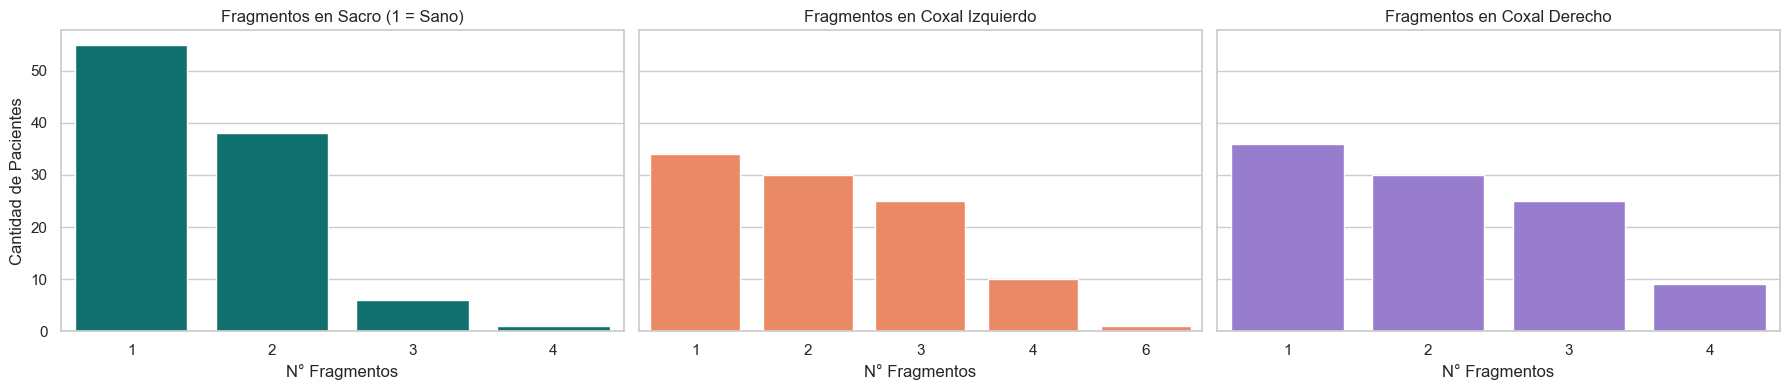

In [8]:
print("=== ANÁLISIS DE FRACTURAS SEGÚN LA TAXONOMÍA PENGWIN ===")
# 1 fragmento = Hueso sano / no fracturado
# >1 fragmentos = Hueso fracturado
df_eda['sacro_fracturado'] = df_eda['n_sacrum_frags'] > 1
df_eda['coxal_izq_fracturado'] = df_eda['n_left_hip_frags'] > 1
df_eda['coxal_der_fracturado'] = df_eda['n_right_hip_frags'] > 1

print(f"Sacro con fractura: {df_eda['sacro_fracturado'].sum()} / {len(df_eda)} ({df_eda['sacro_fracturado'].mean()*100:.1f}%)")
print(f"Coxal Izquierdo con fractura: {df_eda['coxal_izq_fracturado'].sum()} / {len(df_eda)} ({df_eda['coxal_izq_fracturado'].mean()*100:.1f}%)")
print(f"Coxal Derecho con fractura: {df_eda['coxal_der_fracturado'].sum()} / {len(df_eda)} ({df_eda['coxal_der_fracturado'].mean()*100:.1f}%)")

fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharey=True)
sns.countplot(data=df_eda, x="n_sacrum_frags", ax=axes[0], color="teal")
axes[0].set_title("Fragmentos en Sacro (1 = Sano)")
axes[0].set_xlabel("N° Fragmentos")
axes[0].set_ylabel("Cantidad de Pacientes")

sns.countplot(data=df_eda, x="n_left_hip_frags", ax=axes[1], color="coral")
axes[1].set_title("Fragmentos en Coxal Izquierdo")
axes[1].set_xlabel("N° Fragmentos")

sns.countplot(data=df_eda, x="n_right_hip_frags", ax=axes[2], color="mediumpurple")
axes[2].set_title("Fragmentos en Coxal Derecho")
axes[2].set_xlabel("N° Fragmentos")

plt.tight_layout()
plt.savefig(EDA_DIR / "distribucion_fragmentos.png", dpi=300)
plt.show()

In [9]:
print("=== AUDITORÍA FINAL: CASOS LIMPIOS VS CASOS ATÍPICOS / ANOMALÍAS ===")
auditoria = []

for _, r in df_eda.iterrows():
    alertas = []
    if not r['shape_match']:
        alertas.append('Dimensiones incompatibles Imagen vs Máscara')
    if r['n_anomalous_labels'] > 0:
        alertas.append(f'Etiquetas fuera de taxonomía ({r["n_anomalous_labels"]})')
    if r['hu_max'] > 2500:
        alertas.append(f'Artefacto metálico (HU máx {r["hu_max"]:.0f})')
    if r['bone_slice_ratio'] < 0.25:
        alertas.append(f'Baja cobertura ósea axial ({r["bone_slice_ratio"]*100:.1f}%)')
    if r['total_fragments'] == 0:
        alertas.append('Máscara vacía')
        
    estado = 'Atípico / Desafiante' if len(alertas) > 0 else 'Limpio / Confiable'
    auditoria.append({
        'case_id': r['case_id'],
        'estado': estado,
        'n_alertas': len(alertas),
        'observaciones': '; '.join(alertas) if alertas else 'Conforme'
    })

df_auditoria = pd.DataFrame(auditoria)
df_reporte = df_eda.merge(df_auditoria, on='case_id')
df_reporte.to_csv(EDA_DIR / "auditoria_calidad_casos.csv", index=False)

print(f"Resumen de auditoría de calidad:")
print(df_reporte["estado"].value_counts())

casos_atípicos = df_reporte[df_reporte['estado'] != 'Limpio / Confiable']
if len(casos_atípicos) > 0:
    print(f"\nCasos marcados para control previo:")
    display(casos_atípicos[['case_id', 'estado', 'observaciones']].head(15))
else:
    print("\nTodos los casos cumplen perfectamente con los criterios de consistencia.")

=== AUDITORÍA FINAL: CASOS LIMPIOS VS CASOS ATÍPICOS / ANOMALÍAS ===
Resumen de auditoría de calidad:
estado
Limpio / Confiable      53
Atípico / Desafiante    47
Name: count, dtype: int64

Casos marcados para control previo:


,case_id,estado,observaciones
0,001,Atípico / Desafiante,Artefacto metálico (HU máx 2775)
1,002,Atípico / Desafiante,Artefacto metálico (HU máx 4711)
2,003,Atípico / Desafiante,Artefacto metálico (HU máx 16709)
3,004,Atípico / Desafiante,Artefacto metálico (HU máx 4961)
4,005,Atípico / Desafiante,Artefacto metálico (HU máx 4695)
6,007,Atípico / Desafiante,Artefacto metálico (HU máx 19380)
9,010,Atípico / Desafiante,Artefacto metálico (HU máx 7573)
12,013,Atípico / Desafiante,Artefacto metálico (HU máx 16941)
13,014,Atípico / Desafiante,Artefacto metálico (HU máx 4420)
15,016,Atípico / Desafiante,Artefacto metálico (HU máx 3556)
